In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('iris.csv')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df = df.iloc[:,1:]

In [5]:
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,setosa
1,3.0,1.4,0.2,setosa
2,3.2,1.3,0.2,setosa
3,3.1,1.5,0.2,setosa
4,3.6,1.4,0.2,setosa


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
encoder = LabelEncoder()

In [9]:
df['species'] = encoder.fit_transform(df['species'])

In [10]:
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [11]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [12]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

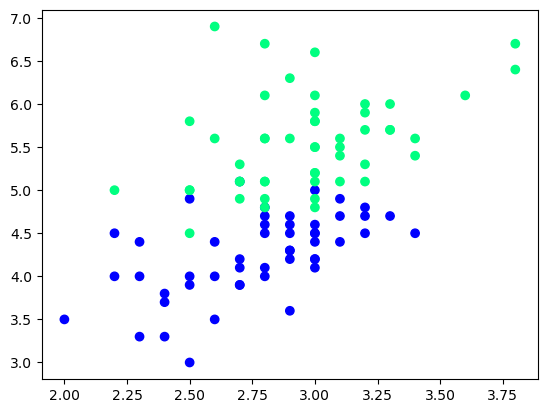

In [15]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [16]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal_width,petal_length,species
100,3.3,6.0,2
84,3.0,4.5,1
107,2.9,6.3,2
54,2.8,4.6,1
98,2.5,3.0,1
104,3.0,5.8,2
75,3.0,4.4,1
83,2.7,5.1,1
60,2.0,3.5,1
80,2.4,3.8,1


In [17]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [18]:
df_train

,sepal_width,petal_length,species
84,3.0,4.5,1
129,3.0,5.8,2
125,3.2,6.0,2
50,3.2,4.7,1
94,2.7,4.2,1
105,3.0,6.6,2
51,3.2,4.5,1
149,3.0,5.1,2
64,2.9,3.6,1
98,2.5,3.0,1


In [19]:
df_val

,sepal_width,petal_length,species
121,2.8,4.9,2
128,2.8,5.6,2
81,2.4,3.7,1
126,2.8,4.8,2
115,3.2,5.3,2


In [20]:
df_test

,sepal_width,petal_length,species
144,3.3,5.7,2
76,2.8,4.8,1
133,2.8,5.1,2
75,3.0,4.4,1
113,2.5,5.0,2


In [21]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [22]:
y_test

array([2, 2, 1, 2, 2])

# Case 1 - Bagging

In [23]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
64,2.9,3.6,1
105,3.0,6.6,2
105,3.0,6.6,2
51,3.2,4.5,1
125,3.2,6.0,2
51,3.2,4.5,1
51,3.2,4.5,1
64,2.9,3.6,1


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [25]:
dt_bag1 = DecisionTreeClassifier()

In [27]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

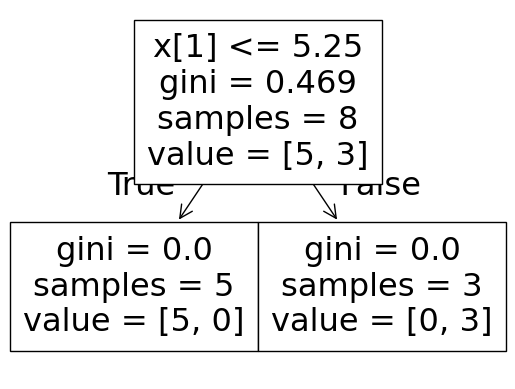

c:\Users\Om\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Om\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


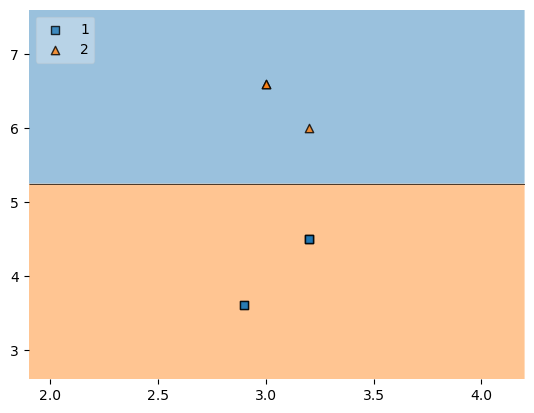

In [28]:
evaluate(dt_bag1,X,y)

In [29]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
94,2.7,4.2,1
51,3.2,4.5,1
149,3.0,5.1,2
50,3.2,4.7,1
50,3.2,4.7,1
84,3.0,4.5,1
105,3.0,6.6,2
94,2.7,4.2,1


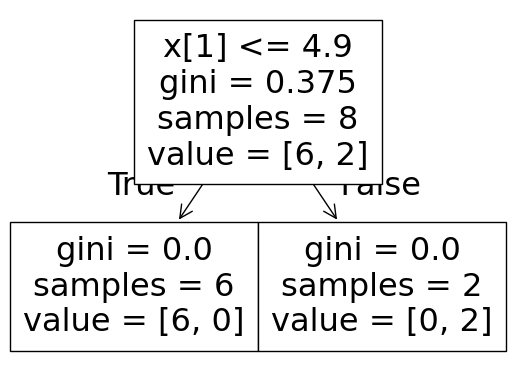

c:\Users\Om\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Om\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


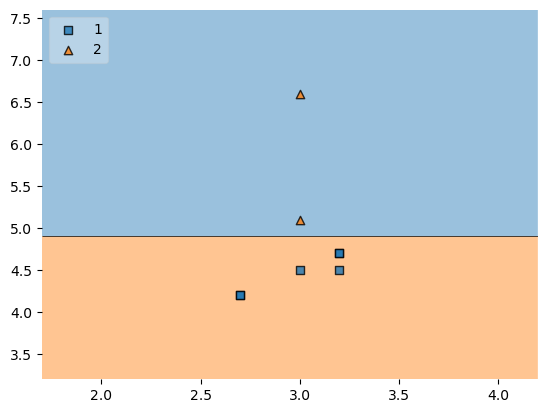

In [30]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [31]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
50,3.2,4.7,1
129,3.0,5.8,2
105,3.0,6.6,2
129,3.0,5.8,2
129,3.0,5.8,2
129,3.0,5.8,2
98,2.5,3.0,1
50,3.2,4.7,1


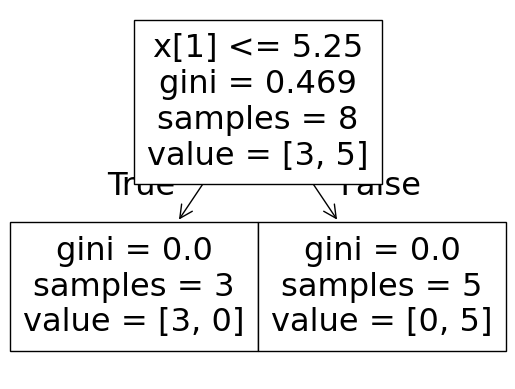

c:\Users\Om\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Om\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


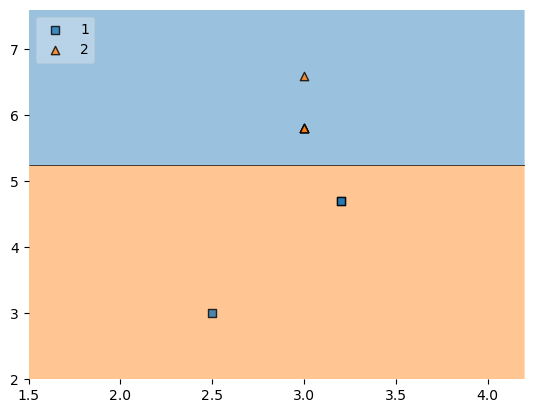

In [32]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [33]:
df_test

,sepal_width,petal_length,species
144,3.3,5.7,2
76,2.8,4.8,1
133,2.8,5.1,2
75,3.0,4.4,1
113,2.5,5.0,2


In [54]:
print("Predictor 1",dt_bag1.predict(np.array([2.8,5.1]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.8,5.1]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.8,5.1]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [2]
Predictor 3 [1]


c:\Users\Om\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Om\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Om\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [45]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
84,3.0,4.5,1
129,3.0,5.8,2
125,3.2,6.0,2
50,3.2,4.7,1
94,2.7,4.2,1
105,3.0,6.6,2
51,3.2,4.5,1
149,3.0,5.1,2
64,2.9,3.6,1
98,2.5,3.0,1


In [46]:
df_train.sample(8)

,sepal_width,petal_length,species
64,2.9,3.6,1
94,2.7,4.2,1
149,3.0,5.1,2
129,3.0,5.8,2
50,3.2,4.7,1
98,2.5,3.0,1
51,3.2,4.5,1
84,3.0,4.5,1


# Random Subspaces

In [47]:
df1 = pd.read_csv('iris.csv')
df1 = df1.sample(10)

In [48]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
144,6.7,3.3,5.7,2.5,virginica
129,7.2,3.0,5.8,1.6,virginica
95,5.7,3.0,4.2,1.2,versicolor
49,5.0,3.3,1.4,0.2,setosa
35,5.0,3.2,1.2,0.2,setosa
127,6.1,3.0,4.9,1.8,virginica
69,5.6,2.5,3.9,1.1,versicolor
4,5.0,3.6,1.4,0.2,setosa
25,5.0,3.0,1.6,0.2,setosa
24,4.8,3.4,1.9,0.2,setosa


In [55]:
df1.sample(2,replace=True,axis=1)

,sepal_width,petal_length
144,3.3,5.7
129,3.0,5.8
95,3.0,4.2
49,3.3,1.4
35,3.2,1.2
127,3.0,4.9
69,2.5,3.9
4,3.6,1.4
25,3.0,1.6
24,3.4,1.9


# Random Patches

In [50]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
144,6.7,3.3,5.7,2.5,virginica
129,7.2,3.0,5.8,1.6,virginica
95,5.7,3.0,4.2,1.2,versicolor
49,5.0,3.3,1.4,0.2,setosa
35,5.0,3.2,1.2,0.2,setosa
127,6.1,3.0,4.9,1.8,virginica
69,5.6,2.5,3.9,1.1,versicolor
4,5.0,3.6,1.4,0.2,setosa
25,5.0,3.0,1.6,0.2,setosa
24,4.8,3.4,1.9,0.2,setosa


In [58]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,sepal_length,petal_width
49,5.0,0.2
4,5.0,0.2
95,5.7,1.2
129,7.2,1.6
25,5.0,0.2
129,7.2,1.6
144,6.7,2.5
129,7.2,1.6
